In [1]:
# Importações necessárias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML 
import os 

In [2]:
# Configuração inicial
np.random.seed(42)
n_transacoes = 200 

In [3]:
# Valores de transação (distribuição normal para a maioria, com algumas exceções)
valores = np.random.normal(loc=100, scale=30, size=n_transacoes)

# Injetar alguns valores atípicos (potenciais fraudes)
valores[np.random.choice(n_transacoes, 10, replace=False)] += np.random.normal(loc=200, scale=50, size=10)

In [4]:
# Níveis de risco (simulando um score de risco para cada transação)
riscos = np.random.uniform(low=0.1, high=0.9, size=n_transacoes)

# Aumentar o risco para transações com valores atípicos
riscos[valores > 180] += np.random.uniform(0.1, 0.3, size=np.sum(valores > 180))
riscos = np.clip(riscos, 0.1, 1.0) # Garante que o risco não exceda 1.0

In [5]:
# Limiar de detecção de fraude
limiar_risco = 0.7

In [6]:
# Classificação inicial (fraudulento ou não)
fraudulento = (riscos > limiar_risco).astype(int)

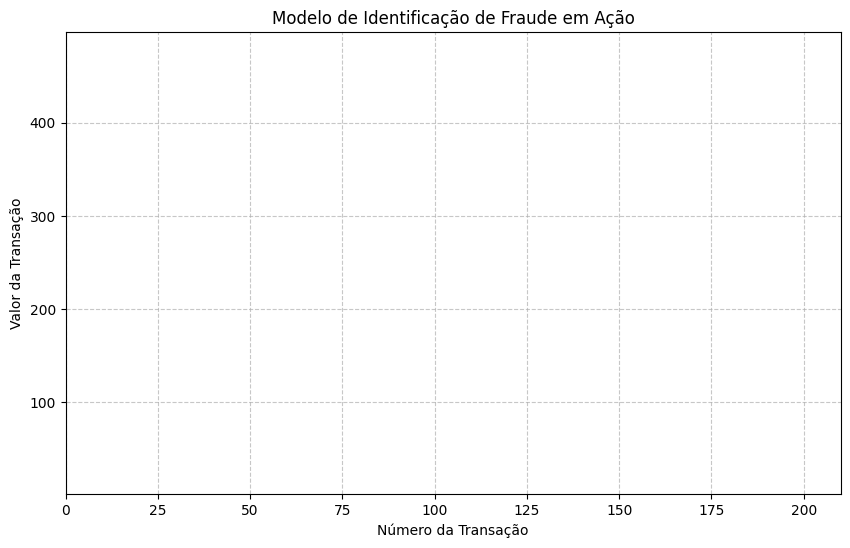

In [7]:
# Configurando o gráfico para a animação 
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, n_transacoes + 10)
ax.set_ylim(min(valores) - 20, max(valores) + 20)
ax.set_xlabel('Número da Transação')
ax.set_ylabel('Valor da Transação')
ax.set_title('Modelo de Identificação de Fraude em Ação')
ax.grid(True, linestyle='--', alpha=0.7)

In [8]:
# Scatter plot inicial (vazio)
scatter = ax.scatter([], [], s=100, alpha=0.7, edgecolors='w', linewidth=0.5)
text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

In [9]:
# Função de atualização para a animação 
def update(frame):
    current_x_data = np.arange(1, frame + 1)
    current_y_data = valores[:frame]
    current_fraud_status = fraudulento[:frame]

    colors = ['blue' if status == 0 else 'red' for status in current_fraud_status]

    scatter.set_offsets(np.c_[current_x_data, current_y_data])
    scatter.set_facecolors(colors)
    
    total_fraudes = sum(current_fraud_status)
    text.set_text(f"Total de fraudes detectadas: {total_fraudes}")
    return scatter, text

### Criação da animação

In [10]:
# Repeat=False para controlar o loop manualmente ao salvar
ani = animation.FuncAnimation(fig, update, frames=n_transacoes, interval=100, repeat=False)

plt.close(fig)

### Definir e criar as pastas de saída

In [11]:
# Se o notebook está em 'notebooks/', e 'media' deve estar na raiz do projeto (mesmo nível de notebooks)
media_folder = os.path.join('..', 'media')

In [12]:
# Criar a pasta 'media' se ela não existir
if not os.path.exists(media_folder):
    os.makedirs(media_folder)
    print(f"Pasta '{media_folder}' criada com sucesso.")

In [13]:
#Salvar como GIF
gif_path = os.path.join(media_folder, 'fraud_detection_animation.gif')

### Observação:

- Para GIFs, geralmente usamos o writer 'pillow'.
- O 'fps' (frames por segundo) controla a velocidade da animação.
- O 'dpi' (dots per inch) afeta a resolução e o tamanho do arquivo.

In [14]:
# Código para salvamento
ani.save(gif_path, writer='pillow', fps=10, dpi=100) 

print(f'\nAnimação salva como {gif_path}')


Animação salva como ..\media\fraud_detection_animation.gif
